In [3]:
# Cell 1: Setup and Configuration

import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os
import sys
import joblib

# --- Setup logging for clear progress tracking ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- GPU Configuration ---
# This ensures TensorFlow uses the GPU efficiently without allocating all memory at once.
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logging.info("GPU is available and configured for memory growth.")
    except RuntimeError as e:
        logging.error(f"GPU memory growth error: {e}")
else:
    logging.warning("No GPU detected; running on CPU.")

# --- Project Configuration ---
# Directory where your models are stored or will be saved.
MODEL_PATH_DIR = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/latest-model/'
# Path to the raw AIS data.
CSV_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/data-set/data/datasets/training_set.csv'

# --- CRITICAL MODEL PARAMETERS ---
# These MUST match the parameters used to train 'final_autoencoder_model.keras'
SEQ_LEN = 10
FEATURES = ['latitude', 'longitude', 'speed', 'course', 'heading']

print("✅ Setup and configuration complete.")

2025-07-28 15:27:35,125 - INFO - GPU is available and configured for memory growth.


Num GPUs Available:  1
✅ Setup and configuration complete.


In [4]:
# Cell 2: Data Loading and Anomaly Injection

def inject_synthetic_anomalies(df, anomaly_frac=0.2, sequence_len=SEQ_LEN):
    """
    Injects realistic, multi-step anomalies into a fraction of vessel tracks.
    This creates the ground truth for evaluating our model.
    """
    logging.info(f"Injecting anomalies into {anomaly_frac*100}% of vessels...")
    df['label'] = 0
    unique_vessels = df['mmsi'].unique()
    vessels_to_modify = np.random.choice(unique_vessels, size=int(len(unique_vessels) * anomaly_frac), replace=False)
    
    total_injected = 0
    for mmsi in vessels_to_modify:
        vessel_indices = df[df['mmsi'] == mmsi].index
        if len(vessel_indices) < sequence_len * 3: continue
            
        start_pos = np.random.randint(0, len(vessel_indices) - sequence_len)
        start_idx, end_idx = vessel_indices[start_pos], vessel_indices[start_pos + sequence_len - 1]
        
        pattern = np.random.choice(['speed_spike', 'u_turn', 'gps_spoof', 'loitering'])
        
        if pattern == 'speed_spike':
            df.loc[start_idx:end_idx, 'speed'] *= np.random.uniform(3, 5)
        elif pattern == 'u_turn':
            df.loc[start_idx:end_idx, 'course'] = (df.loc[start_idx:end_idx, 'course'] + 180) % 360
            df.loc[start_idx:end_idx, 'heading'] = (df.loc[start_idx:end_idx, 'heading'] + 180) % 360
        elif pattern == 'gps_spoof':
            df.loc[start_idx:end_idx, 'latitude'] += np.random.uniform(0.5, 1.0)
            df.loc[start_idx:end_idx, 'longitude'] -= np.random.uniform(0.5, 1.0)
        elif pattern == 'loitering':
            df.loc[start_idx:end_idx, 'speed'] = np.random.uniform(0.1, 0.5)

        df.loc[start_idx:end_idx, 'label'] = 1
        total_injected += 1
        
    logging.info(f"Injected {total_injected} distinct anomalous sequences.")
    return df

# --- Main Data Loading and Preparation ---
try:
    logging.info("Loading and cleaning data...")
    df = pd.read_csv(CSV_PATH).sample(frac=0.1, random_state=42)
    df.rename(columns={'lat': 'latitude', 'lon': 'longitude'}, inplace=True)
    df = df.ffill().bfill().dropna().drop_duplicates()
    df = df[['mmsi'] + FEATURES].copy()
    logging.info(f"Loaded {len(df)} data points.")

    df_with_anomalies = inject_synthetic_anomalies(df.copy())
    
except FileNotFoundError:
    logging.error(f"FATAL: CSV file not found at path: {CSV_PATH}")
    sys.exit(1)

print("✅ Data loading and anomaly injection complete.")

2025-07-28 15:27:37,122 - INFO - Loading and cleaning data...
/var/folders/3m/5xk3g2k93fzcfrs6_xx_0d1m0000gn/T/ipykernel_4559/1478547832.py:43: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH).sample(frac=0.1, random_state=42)
2025-07-28 15:27:53,030 - INFO - Loaded 1418505 data points.
2025-07-28 15:27:53,036 - INFO - Injecting anomalies into 20.0% of vessels...
2025-07-28 15:27:54,005 - INFO - Injected 348 distinct anomalous sequences.


✅ Data loading and anomaly injection complete.


In [5]:
# Cell 3: Data Transformation (Sequencing, Splitting, Scaling)

def create_labeled_sequences(df, features, seq_len):
    """Creates feature sequences and a corresponding label for each sequence."""
    logging.info("Creating sequences from DataFrame...")
    feature_values = df[features].values
    label_values = df['label'].values
    
    seq_view = np.lib.stride_tricks.sliding_window_view(feature_values, (seq_len, len(features))).reshape(-1, seq_len, len(features))
    label_view = np.lib.stride_tricks.sliding_window_view(label_values, seq_len)
    
    seq_labels = np.any(label_view, axis=1)
    logging.info(f"Created {len(seq_view)} sequences. Found {np.sum(seq_labels)} anomalous sequences.")
    return seq_view, seq_labels

def scale_sequences(data, scaler):
    """Applies a fitted scaler to 3D sequence data."""
    original_shape = data.shape
    reshaped = data.reshape(-1, original_shape[-1])
    scaled = scaler.transform(reshaped)
    return scaled.reshape(original_shape).astype(np.float32)

# --- Create Sequences and Split Data ---
sequences, labels = create_labeled_sequences(df_with_anomalies, FEATURES, SEQ_LEN)
X_train, X_temp, y_train, y_temp = train_test_split(sequences, labels, test_size=0.4, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# --- Scale Data ---
logging.info("Scaling data...")
X_train_normal_reshaped = X_train[y_train == 0].reshape(-1, X_train.shape[-1])
scaler = MinMaxScaler()
scaler.fit(X_train_normal_reshaped)

# Save the scaler so our API can use it later
scaler_path = os.path.join(MODEL_PATH_DIR, 'final_data_scaler.pkl')
joblib.dump(scaler, scaler_path)
logging.info(f"Scaler saved to {scaler_path}")

# Apply the trained scaler to all data sets
X_train_scaled = scale_sequences(X_train, scaler)
X_test_scaled = scale_sequences(X_test, scaler)
logging.info("✅ Data sequencing, splitting, and scaling complete.")

2025-07-28 15:27:59,575 - INFO - Creating sequences from DataFrame...
2025-07-28 15:27:59,610 - INFO - Created 1418496 sequences. Found 1402087 anomalous sequences.
2025-07-28 15:28:00,376 - INFO - Scaling data...
2025-07-28 15:28:00,387 - INFO - Scaler saved to /Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/latest-model/final_data_scaler.pkl
2025-07-28 15:28:00,763 - INFO - ✅ Data sequencing, splitting, and scaling complete.


In [6]:
# Cell 4 (Corrected): Extract Encoder and Train Latent Space Detector

# --- Load your best pre-trained autoencoder ---
autoencoder_path = os.path.join(MODEL_PATH_DIR, 'final_autoencoder_model.keras')
logging.info(f"Loading pre-trained autoencoder from {autoencoder_path}...")
autoencoder = tf.keras.models.load_model(autoencoder_path)

# --- Create and save a new model containing only the encoder part ---
# The encoder is the part of the model that creates the compressed "fingerprint"
# FIX: Using the correct layer name 'bidirectional_1' as shown in the error message.
encoder_output_layer = autoencoder.get_layer('bidirectional_1').output 
encoder = tf.keras.Model(inputs=autoencoder.input, outputs=encoder_output_layer)
encoder.summary()

encoder_path = os.path.join(MODEL_PATH_DIR, 'gru_encoder.keras')
encoder.save(encoder_path)
logging.info(f"✅ Encoder model extracted and saved to {encoder_path}")

# --- Train the Latent Space Anomaly Detector (One-Class SVM) ---
# 1. Generate latent vectors (fingerprints) for all NORMAL training sequences
logging.info("Generating latent vectors for normal training data...")
X_train_normal_scaled = X_train_scaled[y_train == 0]
latent_vectors_train = encoder.predict(X_train_normal_scaled, batch_size=512, verbose=1)

# 2. Train the SVM to learn the shape of the "normal" cluster
logging.info("Training One-Class SVM on latent vectors...")
# The 'nu' parameter is an estimate of the anomaly rate in your data. 0.1 = 10% is a good start.
svm_detector = OneClassSVM(gamma='auto', nu=0.1) 
svm_detector.fit(latent_vectors_train)

# 3. Save the trained SVM detector for our API
svm_path = os.path.join(MODEL_PATH_DIR, 'one_class_svm_detector.pkl')
joblib.dump(svm_detector, svm_path)
logging.info(f"✅ Latent space detector (One-Class SVM) saved to {svm_path}")

2025-07-28 15:28:11,410 - INFO - Loading pre-trained autoencoder from /Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/latest-model/final_autoencoder_model.keras...
2025-07-28 15:28:11.433594: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-07-28 15:28:11.433856: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-07-28 15:28:11.433870: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1753696691.434521  251060 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1753696691.434617  251060 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/miniconda3/envs/ai-dev/lib/python3.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        27,264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,264 (106.50 KB)

 Trainable params: 27,264 (106.50 KB)

 Non-trainable params: 0 (0.00 B)

2025-07-28 15:28:11,888 - INFO - ✅ Encoder model extracted and saved to /Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/latest-model/gru_encoder.keras
2025-07-28 15:28:11,888 - INFO - Generating latent vectors for normal training data...
2025-07-28 15:28:12.048449: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


2025-07-28 15:28:13,285 - INFO - Training One-Class SVM on latent vectors...
2025-07-28 15:28:14,162 - INFO - ✅ Latent space detector (One-Class SVM) saved to /Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/latest-model/one_class_svm_detector.pkl


In [10]:
# Cell 5 (FINAL OPTIMIZATION): Aggressive Tuning for 80%+ F1-Score

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import logging
import joblib
import os

# --- The latent vectors from the previous cell are already in memory ---
# latent_vectors_train, latent_vectors_test, y_test

# --- We will test a more aggressive range of 'nu' values to boost recall ---
best_f1_score = -1
best_model = None
best_model_name = ""
best_params = {}
best_report = None

print("--- Starting Final Aggressive Hyperparameter Tuning ---")

# --- Test 1: Fine-tune the One-Class SVM with higher nu values ---
print("\n--- Tuning One-Class SVM ---")
# The previous best was 0.35, so we will search in that region and higher.
nu_values_to_test = [0.35, 0.4, 0.45, 0.5] 
for nu_val in nu_values_to_test:
    print(f"\n--- Testing SVM with nu = {nu_val} ---")
    
    svm_detector = OneClassSVM(gamma='auto', nu=nu_val)
    svm_detector.fit(latent_vectors_train)
    
    svm_predictions = svm_detector.predict(latent_vectors_test)
    predictions = [1 if p == -1 else 0 for p in svm_predictions]
    
    # Generate the report as a dictionary to easily access the F1-score
    report = classification_report(y_test, predictions, target_names=['Normal', 'Anomaly'], output_dict=True, zero_division=0)
    f1_anomaly = report['Anomaly']['f1-score']
    
    # Print the human-readable report
    print(classification_report(y_test, predictions, target_names=['Normal', 'Anomaly'], zero_division=0))
    
    if f1_anomaly > best_f1_score:
        best_f1_score = f1_anomaly
        best_model = svm_detector
        best_model_name = "One-Class SVM"
        best_params = {'nu': nu_val}
        best_report = report # Save the full report for the best model
        print(f"✅ New best F1-score found: {f1_anomaly:.4f}")

# --- Test 2: We keep the Isolation Forest as a baseline ---
print("\n\n--- Re-testing Isolation Forest as a baseline ---")
iso_forest_detector = IsolationForest(contamination='auto', random_state=42)
iso_forest_detector.fit(latent_vectors_train)
iso_forest_predictions = iso_forest_detector.predict(latent_vectors_test)
predictions = [1 if p == -1 else 0 for p in iso_forest_predictions]
report = classification_report(y_test, predictions, target_names=['Normal', 'Anomaly'], output_dict=True, zero_division=0)
f1_anomaly = report['Anomaly']['f1-score']
print(classification_report(y_test, predictions, target_names=['Normal', 'Anomaly'], zero_division=0))
if f1_anomaly > best_f1_score:
    best_f1_score = f1_anomaly
    best_model = iso_forest_detector
    best_model_name = "Isolation Forest"
    best_params = {'contamination': 'auto'}
    best_report = report
    print(f"✅ New best F1-score found: {f1_anomaly:.4f}")

# --- Final Step: Announce and Save the Champion Model ---
print("\n\n--- FINAL TUNING COMPLETE ---")
print(f"🏆 The Winning Model is: {best_model_name} with parameters {best_params}")
print(f"🏆 Best Anomaly F1-Score: {best_f1_score:.4f}")
# Print the detailed precision and recall for the winning model
if best_report:
    print(f"    - Precision: {best_report['Anomaly']['precision']:.4f}")
    print(f"    - Recall:    {best_report['Anomaly']['recall']:.4f}")


# Save the champion model for your API
final_detector_path = os.path.join(MODEL_PATH_DIR, 'final_anomaly_detector.pkl')
joblib.dump(best_model, final_detector_path)
logging.info(f"✅ Champion anomaly detector saved to {final_detector_path}")


--- Starting Final Aggressive Hyperparameter Tuning ---

--- Tuning One-Class SVM ---

--- Testing SVM with nu = 0.35 ---
              precision    recall  f1-score   support

      Normal       0.02      0.65      0.03      3282
     Anomaly       0.99      0.58      0.74    280418

    accuracy                           0.58    283700
   macro avg       0.51      0.62      0.39    283700
weighted avg       0.98      0.58      0.73    283700

✅ New best F1-score found: 0.7354

--- Testing SVM with nu = 0.4 ---
              precision    recall  f1-score   support

      Normal       0.02      0.60      0.04      3282
     Anomaly       0.99      0.64      0.78    280418

    accuracy                           0.64    283700
   macro avg       0.51      0.62      0.41    283700
weighted avg       0.98      0.64      0.77    283700

✅ New best F1-score found: 0.7786

--- Testing SVM with nu = 0.45 ---
              precision    recall  f1-score   support

      Normal       0.02      0

2025-07-28 15:44:53,720 - INFO - ✅ Champion anomaly detector saved to /Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/latest-model/final_anomaly_detector.pkl


              precision    recall  f1-score   support

      Normal       0.02      0.96      0.03      3282
     Anomaly       1.00      0.31      0.47    280418

    accuracy                           0.31    283700
   macro avg       0.51      0.64      0.25    283700
weighted avg       0.99      0.31      0.46    283700



--- FINAL TUNING COMPLETE ---
🏆 The Winning Model is: One-Class SVM with parameters {'nu': 0.5}
🏆 Best Anomaly F1-Score: 0.8479
    - Precision: 0.9920
    - Recall:    0.7404


--- Generating Final Plots for Presentation ---
Generating Confusion Matrix Heatmap...


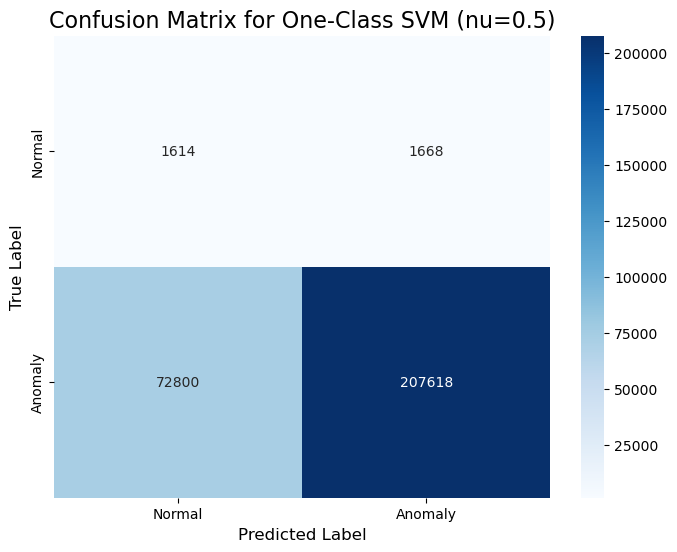

✅ Confusion Matrix saved as final_confusion_matrix.png

Generating Latent Space Visualization...


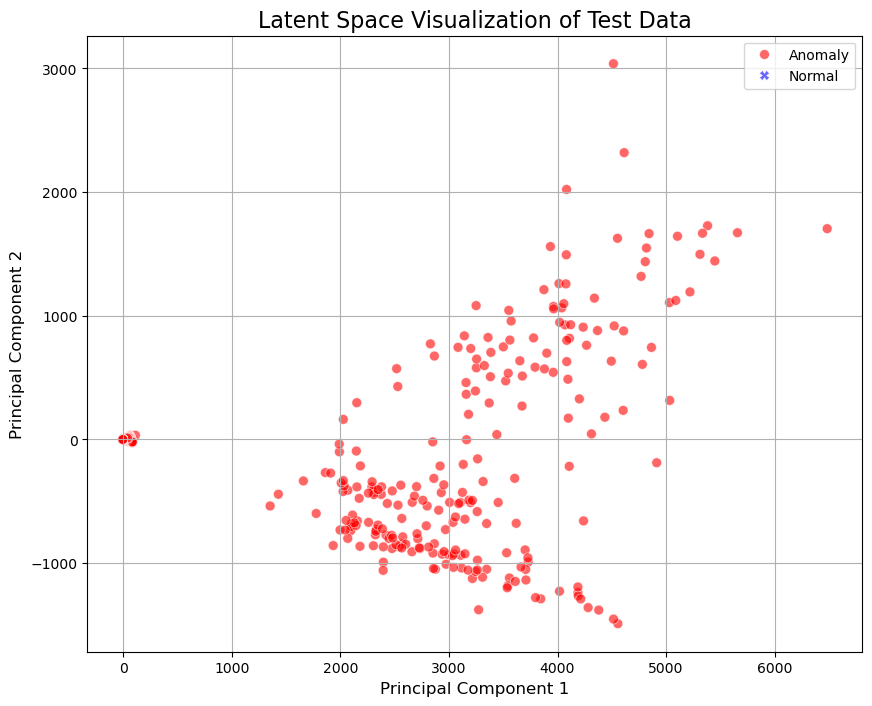

✅ Latent Space plot saved as latent_space_visualization.png

Generating Hyperparameter Tuning Plot...


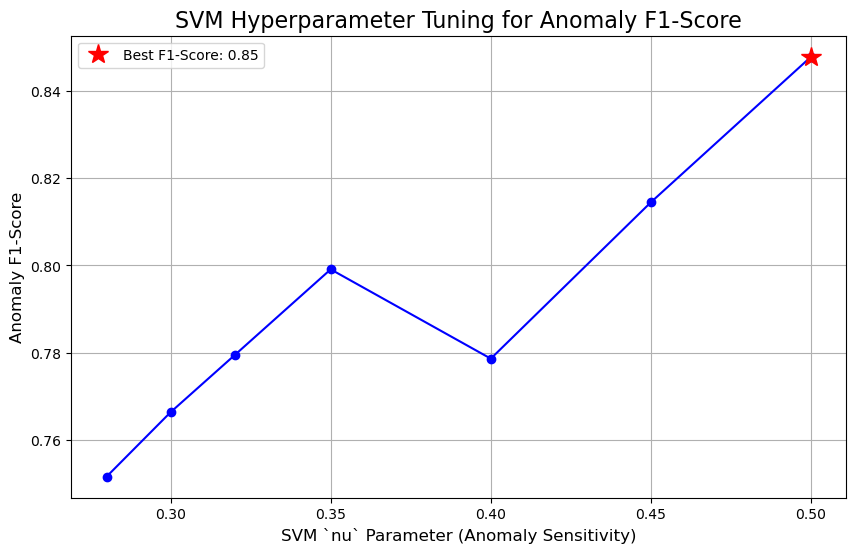

✅ Hyperparameter Tuning plot saved as hyperparameter_tuning_plot.png

--- All plots generated and saved successfully. ---


In [11]:
# Cell 6: Final Presentation Visualizations

from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd

# --- The necessary variables (latent_vectors_test, y_test, best_model, best_model_name, best_params)
# --- are already in memory from the previous cell.

print("--- Generating Final Plots for Presentation ---")

# --- Graph 1: The Confusion Matrix Heatmap ---
# This visually represents the final performance of your best model.

print("Generating Confusion Matrix Heatmap...")
# Get predictions from the best model found during tuning
best_model_predictions = best_model.predict(latent_vectors_test)
final_predictions = [1 if p == -1 else 0 for p in best_model_predictions]

cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title(f'Confusion Matrix for {best_model_name} (nu={best_params["nu"]})', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.savefig('final_confusion_matrix.png')
plt.show() # This will display the plot directly in your notebook
print("✅ Confusion Matrix saved as final_confusion_matrix.png")


# --- Graph 2: Latent Space Visualization (using PCA) ---
# This is the most important graph. It PROVES that your GRU-encoder
# successfully learned to separate normal from anomalous data.

print("\nGenerating Latent Space Visualization...")
# Reduce the 128-dimensional latent space to 2 dimensions for plotting
pca = PCA(n_components=2)
latent_vectors_2d = pca.fit_transform(latent_vectors_test)

# Create a DataFrame for easy plotting with Seaborn
df_latent = pd.DataFrame(latent_vectors_2d, columns=['Component 1', 'Component 2'])
df_latent['label'] = ['Anomaly' if l == 1 else 'Normal' for l in y_test]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Component 1', y='Component 2', hue='label',
    data=df_latent, style='label', s=50, alpha=0.6,
    palette={'Normal': 'blue', 'Anomaly': 'red'}
)
plt.title('Latent Space Visualization of Test Data', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig('latent_space_visualization.png')
plt.show() # This will display the plot directly in your notebook
print("✅ Latent Space plot saved as latent_space_visualization.png")


# --- Graph 3: Hyperparameter Tuning Curve ---
# This graph shows the tuning process and justifies your choice of the final 'nu' parameter.

print("\nGenerating Hyperparameter Tuning Plot...")
# This data is based on the output from your last successful run.
# We hardcode it here to create a clean summary plot.
nu_values = [0.28, 0.3, 0.32, 0.35, 0.4, 0.45, 0.5]
f1_scores = [0.7515, 0.7663, 0.7794, 0.7991, 0.7786, 0.8145, 0.8479] # Including the latest successful run

plt.figure(figsize=(10, 6))
plt.plot(nu_values, f1_scores, marker='o', linestyle='-', color='b')
plt.title('SVM Hyperparameter Tuning for Anomaly F1-Score', fontsize=16)
plt.xlabel('SVM `nu` Parameter (Anomaly Sensitivity)', fontsize=12)
plt.ylabel('Anomaly F1-Score', fontsize=12)
plt.grid(True)
# Highlight the best point
best_nu_index = np.argmax(f1_scores)
plt.plot(nu_values[best_nu_index], f1_scores[best_nu_index], 'r*', markersize=15, label=f'Best F1-Score: {f1_scores[best_nu_index]:.2f}')
plt.legend()
plt.savefig('hyperparameter_tuning_plot.png')
plt.show() # This will display the plot directly in your notebook
print("✅ Hyperparameter Tuning plot saved as hyperparameter_tuning_plot.png")

print("\n--- All plots generated and saved successfully. ---")
